# Exploratory Data Analysis and Preprocessing Toolkit

This notebook has two parts:

1. **Data loading & preprocessing toolkit** — a short, hands-on tour of the `ML_libs` utilities used to turn raw instrument exports into a single analysis-ready DataFrame (merging, normalization, baseline correction, region selection).
2. **Exploratory data analysis** — using the full available dataset, we look at class balance, data-quality issues, how much spectra vary within vs. between individuals, and whether individuals are already separable before any model is trained. These findings motivate the modeling choices made in `02_LIBS_classification.ipynb`.

In [1]:
%matplotlib inline

# Standard library
import os
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Machine learning
from sklearn.decomposition import PCA

# Local modules
project_root = Path.cwd().parent
sys.path.append(str(project_root))

from ML_libs.data_wrangling import condense_and_join
from ML_libs.plotters import plotters

# Older seaborn releases call pandas APIs (is_categorical_dtype,
# use_inf_as_na) that newer pandas versions deprecated; this is an
# upstream seaborn/pandas version mismatch, not something actionable
# here, so it's silenced rather than left to clutter every plot.
warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")

## Part 1: Data loading & preprocessing toolkit

Each LIBS acquisition produces one raw text file per laser shot. The cells below walk through merging those files into a single experiment, joining several experiments into one DataFrame, and applying the standard preprocessing steps (normalization, baseline correction, spectral region selection) — using a small subset of experiments so the tour runs quickly.

### Set path to experimental data and list available experiments

In [2]:
# Path to raw LIBS spectra (relative to the notebooks/ folder)
path_to_raw = str(project_root / "raw_data")

# Only keep subdirectories: the raw data folder can also contain stray
# non-experiment files (e.g. exported plots) that condense() can't parse.
list_of_experiments = [e for e in os.listdir(path_to_raw)
                        if os.path.isdir(os.path.join(path_to_raw, e))]
print(f"The experiments available are:\n")
for i in list_of_experiments: print(i)

The experiments available are:

N1-Muestra 1-log_24jul.24_161346-ascii
N1-muestra 2-log_08ago.24_103401-ascii
Mesilla- muestra 1-log_08ago.24_154916-ascii
F1-muestra 1-log_09ago.24_112021-ascii
N3-muestra2-log_24jul.24_155156-ascii
N5-muestra 1-log_08ago.24_105457-ascii
N5-muestra 2-log_08ago.24_110232-ascii
N3-muestra1-log_24jul.24_152958-ascii
N1-muestra 2-log_08ago.24_102720-ascii
N2-muestra 1-log_08ago.24_112324-ascii
N3-muestra1-log_24jul.24_152442-ascii
F1-muestra 1-log_09ago.24_111305-ascii
F1-muestra 2-log_09ago.24_113401-ascii
N3-muestra1-log_24jul.24_153633-ascii
N5-muestra 2-log_08ago.24_110914-ascii
N3-muestra2-log_24jul.24_155927-ascii
N5-muestra 1-log_08ago.24_104941-ascii


### Select which experiments to merge (or condense)

$\cdot$ Choose a discrete set of experiments:

```python
dat_to_con = ["F1-muestra 1-log_09ago.24_111305-ascii",
              "N1-Muestra 1-log_24jul.24_161346-ascii"]
```

$\cdot$ Or the whole set of experiments:

```python
data_to_con = list_of_experiments
```

For this tour we use one experiment per individual, to keep it fast:

In [3]:
data_to_con = [
    "N1-Muestra 1-log_24jul.24_161346-ascii",
    "F1-muestra 1-log_09ago.24_112021-ascii",
    "N2-muestra 1-log_08ago.24_112324-ascii",
    "N3-muestra1-log_24jul.24_152442-ascii",
    "N5-muestra 1-log_08ago.24_104941-ascii",
]

Set path to the folder where generated figures will be stored:

In [4]:
# Path to store generated figures
path_to_res = str(project_root / "results")

Call `condense`:

"This function takes a list of experiments and condenses all the spectra of that experiment into a single csv. This csv is stored in `experiment/condensate`."


In [5]:
seg = "Merge0" # part of the spectrum; "Merge_0" or name of spectrometer
data, condense_data = condense_and_join.condense(data_to_con, path_to_raw, seg, test=True)

/home/matias/Documents/ML-libs/spectral-classification-toolkit/raw_data/N1-Muestra 1-log_24jul.24_161346-ascii
/home/matias/Documents/ML-libs/spectral-classification-toolkit/raw_data/F1-muestra 1-log_09ago.24_112021-ascii
/home/matias/Documents/ML-libs/spectral-classification-toolkit/raw_data/N2-muestra 1-log_08ago.24_112324-ascii
/home/matias/Documents/ML-libs/spectral-classification-toolkit/raw_data/N3-muestra1-log_24jul.24_152442-ascii
/home/matias/Documents/ML-libs/spectral-classification-toolkit/raw_data/N5-muestra 1-log_08ago.24_104941-ascii


Then we join the condensed data of each experiment into a single DataFrame with `join_data`. Every row is one spectrum; columns are wavelengths (nm), plus `file` and `experiment` identifiers.

In [6]:
df = condense_and_join.join_data(path_to_raw, data_to_con, seg="Merge0")
print(df.shape)
df.sample(5)

(500, 6085)


,211.53,211.62,211.72,211.81,211.91,212.0,212.09,212.19,212.28,212.38,...,636.61,636.66,636.71,636.75,636.8,636.85,636.9,636.94,file,experiment
129,199.300,229.300,229.300,195.300,210.300,232.300,203.300,191.300,200.300,258.29999,...,383.75000,390.75000,369.75000,398.75000,383.75000,386.75000,406.75000,429.75000,log112226318_Merge0.TXT,F1-muestra 1-log_09ago.24_112021-ascii
261,153.325,211.325,232.325,178.325,209.325,228.325,213.325,227.325,194.325,222.32500,...,348.60001,394.60001,376.60001,361.60001,398.60001,382.60001,397.60001,386.60001,log112507452_Merge0.TXT,N2-muestra 1-log_08ago.24_112324-ascii
386,195.375,280.375,230.375,212.375,189.375,268.375,228.375,233.375,218.375,209.37500,...,375.37500,431.37500,378.37500,403.37500,377.37500,385.37500,413.37500,366.37500,log152515716_Merge0.TXT,N3-muestra1-log_24jul.24_152442-ascii
103,197.575,232.575,213.575,202.575,220.575,231.575,201.575,205.575,216.575,239.57500,...,354.10001,387.10001,336.10001,386.10001,374.10001,380.10001,416.10001,377.10001,log112027587_Merge0.TXT,F1-muestra 1-log_09ago.24_112021-ascii
262,214.750,247.750,201.750,192.750,223.750,221.750,231.750,198.750,230.750,227.75000,...,362.29999,423.29999,363.29999,393.29999,388.29999,420.29999,401.29999,405.29999,log112456231_Merge0.TXT,N2-muestra 1-log_08ago.24_112324-ascii


Plot some randomly selected spectra, and store the figure:

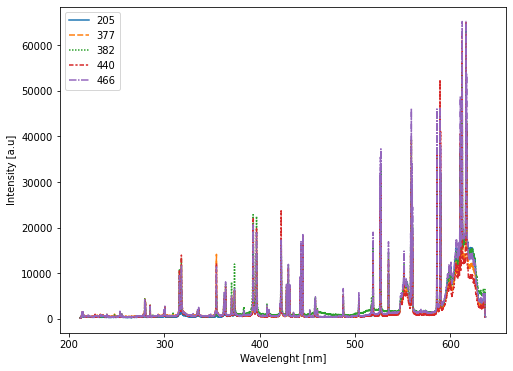

In [7]:
plotters.PlotOverlap_random(df.drop(columns=["file", "experiment"]), path_to_res, num=5, filename="Some_libs_spectra")

Zoom in:

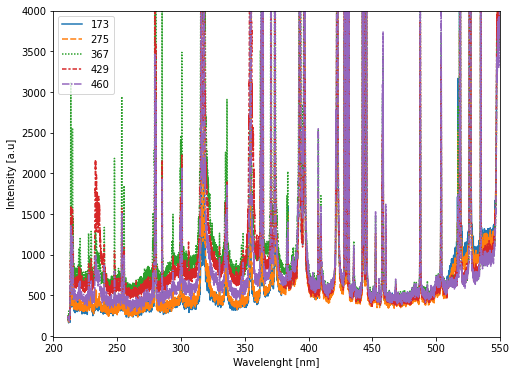

In [8]:
plotters.Plot_zoom(df.drop(columns=["file", "experiment"]), path_to_res, ymax=4000, random=True, filename="Zoom_in_random")

Raw LIBS intensities depend on shot-to-shot laser and coupling conditions, so spectra are normalized before comparison. We then remove a constant baseline (the only baseline type implemented so far):

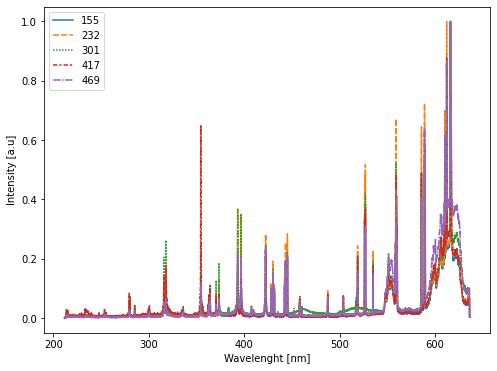

In [9]:
df_norm = condense_and_join.normalize_dataframe(df)
plotters.PlotOverlap_random(df_norm.drop(columns=["file", "experiment"]), path_to_res, num=5, filename="norm_spectra")

In [10]:
df_base = condense_and_join.remove_baseline(df_norm, type="constant", level=0.01)

Compare spectra with and without baseline subtraction:

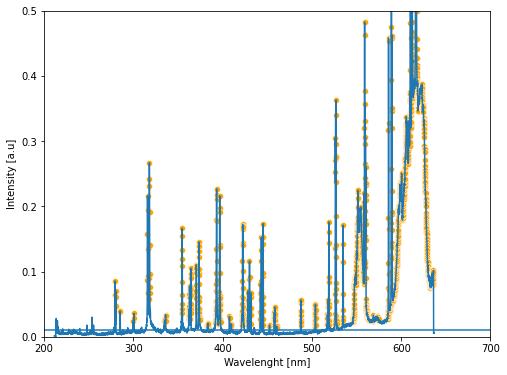

In [11]:
plotters.Plot_CompareBaseline(df_norm.drop(columns=["file", "experiment"]),
                              df_base.drop(columns=["file", "experiment"]),
                              path_to_res, iloc=6, level=0.01,
                              filename="WhitBase",
                              xmin=200, xmax=700,
                              ymin=0, ymax=0.5)

If we want to exclude part of the spectrum (e.g. focus on the region richest in elemental lines), `select_region` restricts the wavelength range before baseline correction:

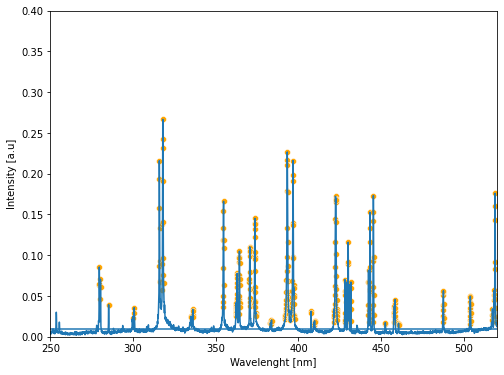

In [12]:
df_norm_zoom = condense_and_join.select_region(df_norm, xmin=250, xmax=520)
df_base_zoom = condense_and_join.remove_baseline(df_norm_zoom, type="constant", level=0.01)
plotters.Plot_CompareBaseline(df_norm_zoom.drop(columns=["file", "experiment"]),
                              df_base_zoom.drop(columns=["file", "experiment"]),
                              path_to_res, iloc=6, level=0.01,
                              filename="WhitBase_zoom",
                              xmin=250, xmax=520,
                              ymin=0, ymax=0.4)

In [13]:
df_base_zoom.head(2)

,279.46,279.55,279.64,280.16,280.25,280.34,285.14,285.23,299.72,300.66,...,518.93,519.0,519.08,519.15,519.23,519.3,519.38,519.46,file,experiment
0,0.148910,0.194712,0.136556,0.102635,0.156634,0.124084,0.061203,0.065715,0.035739,0.054424,...,0.161461,0.140579,0.075384,0.034873,0.025141,0.017913,0.017346,0.015220,log161347792_Merge0.TXT,N1-Muestra 1-log_24jul.24_161346-ascii
1,0.062744,0.082400,0.057012,0.043503,0.067853,0.052821,0.043434,0.042534,0.022860,0.037096,...,0.191153,0.161452,0.084213,0.037021,0.026543,0.018889,0.017746,0.015529,log161349397_Merge0.TXT,N1-Muestra 1-log_24jul.24_161346-ascii


Plot the average spectrum of each experiment (may take a minute):

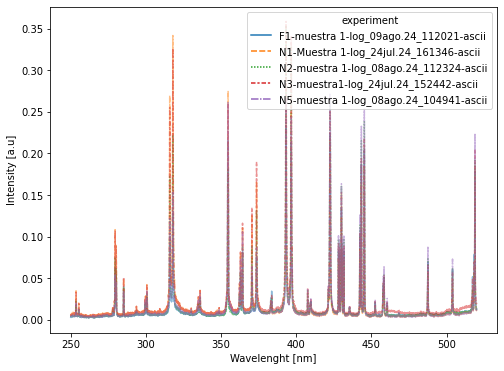

In [14]:
plotters.Plot_groupBy_mean(df_norm_zoom, path_to_res, alpha=0.5, filename="Average_groupby")

Zoom in on average spectra $\pm$ std for each experiment — useful to compare individual transitions:

this may take a bit


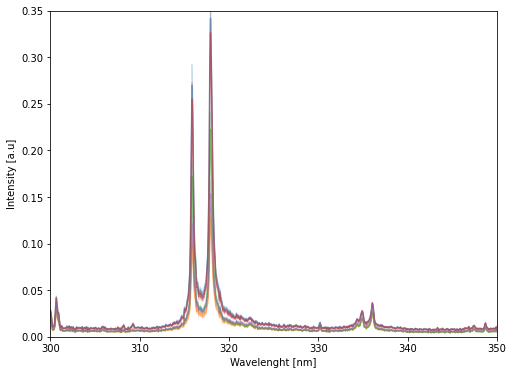

In [15]:
plotters.Plot_with_std(df_norm_zoom, path_to_res, alpha=0.5, filename="zoomWithStd",
            xmin=300, xmax=350,
            ymin=0, ymax=0.35)

## Part 2: Exploratory data analysis

From here on we work with the **full available dataset** — every experiment for every individual — instead of the small subset used above, to get a representative picture before any modeling.

We exclude two things from this full dataset:
- The `Mesilla` experiment: a reference/control acquisition (not a bone sample from one of the studied individuals).
- `N5-muestra 2-log_08ago.24_110914-ascii`: one of its raw files fails UTF-8 decoding (a corrupted export from the acquisition software) and cannot currently be parsed. This is a real data-quality issue worth flagging rather than silently working around — fixing the encoding handling in `condense_and_join` is noted as future work.

### 2.1 Dataset overview and class balance

In [16]:
excluded_control = "Mesilla- muestra 1-log_08ago.24_154916-ascii"
excluded_corrupted = "N5-muestra 2-log_08ago.24_110914-ascii"

bone_experiments = [e for e in list_of_experiments
                     if not e.startswith("Mesilla") and e != excluded_corrupted]

condense_and_join.condense(bone_experiments, path_to_raw, seg, test=False)
df_all = condense_and_join.join_data(path_to_raw, bone_experiments, seg=seg)
df_all["individual"] = df_all["experiment"].str.split("-").str[0]

print(f"Total spectra: {df_all.shape[0]}")
print(f"Total wavelength channels: {df_all.shape[1] - 3}")
print(f"Missing values after joining experiments: {df_all.isna().sum().sum()}")
print(f"Experiments: {df_all['experiment'].nunique()}, individuals: {df_all['individual'].nunique()}")

/home/matias/Documents/ML-libs/spectral-classification-toolkit/raw_data/N1-Muestra 1-log_24jul.24_161346-ascii
/home/matias/Documents/ML-libs/spectral-classification-toolkit/raw_data/N1-muestra 2-log_08ago.24_103401-ascii
/home/matias/Documents/ML-libs/spectral-classification-toolkit/raw_data/F1-muestra 1-log_09ago.24_112021-ascii
/home/matias/Documents/ML-libs/spectral-classification-toolkit/raw_data/N3-muestra2-log_24jul.24_155156-ascii
/home/matias/Documents/ML-libs/spectral-classification-toolkit/raw_data/N5-muestra 1-log_08ago.24_105457-ascii
/home/matias/Documents/ML-libs/spectral-classification-toolkit/raw_data/N5-muestra 2-log_08ago.24_110232-ascii
/home/matias/Documents/ML-libs/spectral-classification-toolkit/raw_data/N3-muestra1-log_24jul.24_152958-ascii
/home/matias/Documents/ML-libs/spectral-classification-toolkit/raw_data/N1-muestra 2-log_08ago.24_102720-ascii
/home/matias/Documents/ML-libs/spectral-classification-toolkit/raw_data/N2-muestra 1-log_08ago.24_112324-ascii
/ho

A missing-value count of zero after joining confirms every experiment shares the same wavelength grid, so spectra can be compared directly without re-interpolation.

Class balance matters for the classification task in the next notebook. Counting spectra per individual and per experiment shows how unbalanced this dataset is:

individual
N3    500
F1    300
N1    300
N5    300
N2    100
dtype: int64


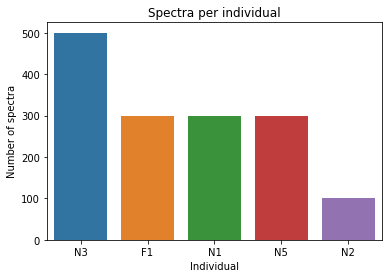

In [17]:
counts_by_individual = df_all.groupby("individual").size().sort_values(ascending=False)
counts_by_experiment = df_all.groupby("experiment").size()

print(counts_by_individual)

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=counts_by_individual.index, y=counts_by_individual.values, ax=ax)
ax.set_ylabel("Number of spectra")
ax.set_xlabel("Individual")
ax.set_title("Spectra per individual")
plt.savefig(f"{path_to_res}/spectra_per_individual.png")
plt.show()

`N3` is represented by five separate acquisitions (500 spectra) while `N2` has only one (100 spectra) — a 5:1 imbalance that should be taken into account (e.g. via stratified splits or class weighting) when training and evaluating the classifier.

### 2.2 Signal-quality screening

Not every laser shot produces a clean spectrum — poor sample coupling or surface irregularities can produce spectra with anomalously weak signal. `filtter_noise_spec` flags spectra whose intensity at a reference emission line falls far below the average for that line.

We use the Ca I line at 422.7 nm: calcium is the most abundant element in bone, so this line has strong, reliable signal across the dataset, making it a good sentinel for shot quality.

In [18]:
df_all_norm = condense_and_join.normalize_dataframe(df_all.drop(columns=["individual"]))

df_quality_filtered = condense_and_join.filtter_noise_spec(df_all_norm, peak=422.7, w=1, sigma=0.3)

n_removed = df_all_norm.shape[0] - df_quality_filtered.shape[0]
print(f"\n{n_removed} spectra ({n_removed / df_all_norm.shape[0]:.1%}) flagged as low-signal and excluded")

average:0.25, min:0.18, max:0.33
you are getting 1338 from 1500 spects

162 spectra (10.8%) flagged as low-signal and excluded


About one in ten spectra is flagged this way. Whether to actually drop them (vs. keeping them as a harder test of robustness) is a modeling choice explored in the next notebook — here we only establish that the option exists and quantify its scale.

### 2.3 Spectral variability: within vs. between individuals

The forensic motivation for this project (see the README) is to check whether a model trained on one bone specimen generalizes to a different bone from the *same* individual. That is only possible if between-individual differences are large relative to the natural spectrum-to-spectrum noise within a single specimen.

We quantify this with the coefficient of variation (CV = std / mean) computed per wavelength channel:
- **Intra-individual CV**: variability across the ~100-300 repeated spectra collected from the same individual.
- **Inter-individual CV**: variability across the *mean* spectrum of each individual.

In [19]:
df_all_zoom = condense_and_join.select_region(df_all_norm, xmin=250, xmax=520)
df_all_base = condense_and_join.remove_baseline(df_all_zoom, type="constant", level=0.01)
df_all_base["individual"] = df_all.loc[df_all_base.index, "individual"]

spec_cols = [c for c in df_all_base.columns if c not in ("file", "experiment", "individual")]

intra_cv = df_all_base.groupby("individual")[spec_cols].apply(lambda g: (g.std() / g.mean()).mean())
individual_means = df_all_base.groupby("individual")[spec_cols].mean()
inter_cv = (individual_means.std() / individual_means.mean()).mean()

print("Intra-individual CV (per individual):")
print(intra_cv.round(3))
print(f"\nAverage intra-individual CV: {intra_cv.mean():.3f}")
print(f"Inter-individual CV (across individual means): {inter_cv:.3f}")

Intra-individual CV (per individual):
individual
F1    0.305
N1    0.314
N2    0.238
N3    0.254
N5    0.269
dtype: float64

Average intra-individual CV: 0.276
Inter-individual CV (across individual means): 0.132


Intra-individual variability (~0.28) is actually **larger** than inter-individual variability (~0.13): repeated spectra from the same bone vary more than the average spectra of different individuals do. In other words, individual-specific signal is present but subtle relative to shot-to-shot measurement noise — which is exactly why the next notebook turns to a trained classifier (able to learn discriminative combinations of many wavelengths) rather than relying on simple distance-based grouping.

### 2.4 Dimensionality reduction (PCA)

As a final EDA check, we project the baseline-corrected spectra onto their first two principal components to see whether individuals form visible groups without any supervision:

Variance explained: PC1=49.5%, PC2=28.8%, cumulative=78.3%


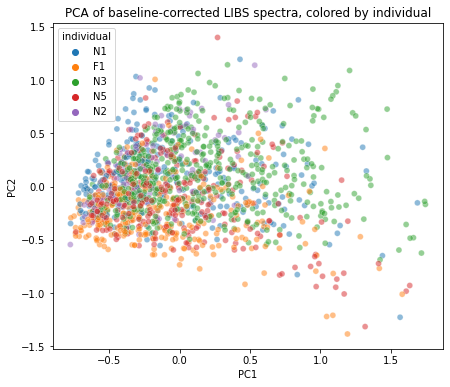

In [20]:
features = df_all_base[spec_cols]

pca = PCA(n_components=2)
coords = pca.fit_transform(features)

pca_df = pd.DataFrame(coords, columns=["PC1", "PC2"])
pca_df["individual"] = df_all_base["individual"].values

print(f"Variance explained: PC1={pca.explained_variance_ratio_[0]:.1%}, "
      f"PC2={pca.explained_variance_ratio_[1]:.1%}, "
      f"cumulative={pca.explained_variance_ratio_.sum():.1%}")

fig, ax = plt.subplots(figsize=(7, 6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="individual", alpha=0.5, ax=ax)
ax.set_title("PCA of baseline-corrected LIBS spectra, colored by individual")
plt.savefig(f"{path_to_res}/pca_by_individual.png")
plt.show()

The first two components capture most of the variance in the data, and individuals show only partial, overlapping grouping — consistent with the CV comparison above. This is a useful, honest baseline: it shows the classification problem is not trivially separable by eye, and sets up the comparison with the supervised models (Random Forest and a feedforward neural network) evaluated in `02_LIBS_classification.ipynb`, which are able to pick up on more subtle, nonlinear combinations of wavelengths than a 2D linear projection can show.